In [15]:
import numpy as np
from astropy.table import Table, join
from gaiaxpy import calibrate

import matplotlib.pyplot as plt

In [16]:
import h5py

# Load spectra from get_spectra output (use sampled for direct flux vs wavelength)
#fn_spectra = '../data/quaia_xp_spectra_sampled.h5'
#fn_spectra = '../data/quaia_xp_spectra_continuous.h5'
fn_spectra = '../data/quaia_xp_spectra_calibrated.h5'
# Fallback to continuous if sampled doesn't exist or is empty
try:
    with h5py.File(fn_spectra, 'r') as f:
        n_spec = f['meta']['source_id'].shape[0]
except (OSError, KeyError):
    raise FileNotFoundError(f'File {fn_spectra} not found')

with h5py.File(fn_spectra, 'r') as f:
    source_ids = f['meta']['source_id'][:]
    wave_bp = f['spectra']['wave_bp'][:]
    wave_rp = f['spectra']['wave_rp'][:]
    flux_bp = f['spectra']['flux_bp'][:]
    flux_rp = f['spectra']['flux_rp'][:]
    print(wave_bp.shape)
    print(flux_bp.shape)

n_spec = len(source_ids)
print(f'Loaded {n_spec} spectra from {fn_spectra}')

# Load QUAIA catalog for redshift
tab_quaia = Table.read('../data/quaia_G20.5.fits')
redshift_dict = dict(zip(tab_quaia['source_id'], tab_quaia['redshift_quaia']))
z_arr = np.array([redshift_dict.get(sid, np.nan) for sid in source_ids])

(343,)
(100, 343)
Loaded 100 spectra from ../data/quaia_xp_spectra_calibrated.h5


/var/folders/r3/x5f9h97x5yxcdy7qv3t1pr7m0000gn/T/ipykernel_76867/3734174113.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


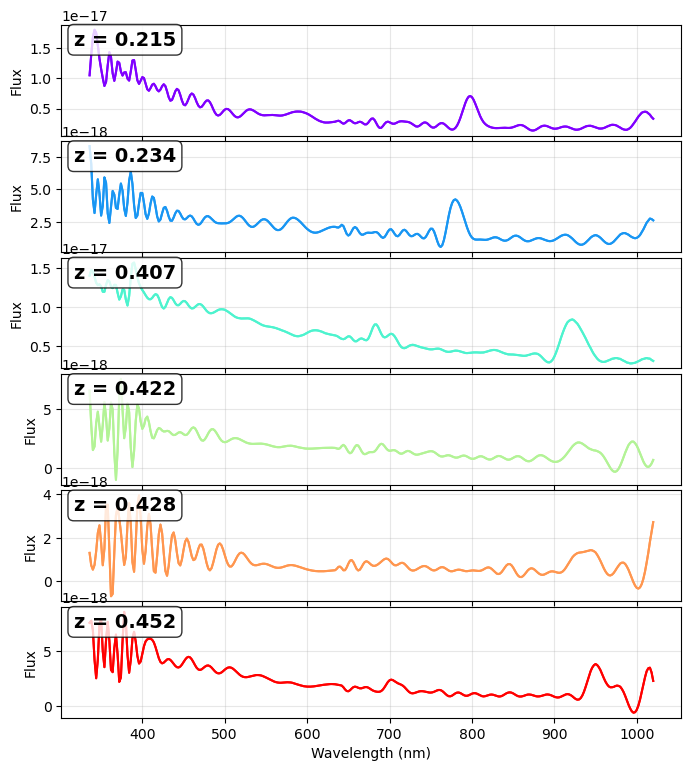

In [17]:
n_plot = 6  # number of spectra to plot in subpanels
n_plot = min(n_plot, n_spec)

# Order by redshift (low to high)
idx_valid = np.isfinite(z_arr)
order = np.argsort(np.where(idx_valid, z_arr, np.inf))
idx_plot = order[:n_plot]

# Subplot layout: one row per spectrum, wide plots (like final cell)
n_rows = n_plot
n_cols = 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8, 1.5 * n_plot),
                         sharex=True, gridspec_kw={'hspace': 0.05})
if n_plot == 1:
    axes = np.array([axes])
axes = axes.flatten()

colors = plt.cm.rainbow(np.linspace(0, 1, n_plot))

for idx, i in enumerate(idx_plot):
    ax = axes[idx]
    z = z_arr[i]
    c = colors[idx]
    ax.plot(wave_bp, flux_bp[i], color=c, linewidth=1.5)
    ax.plot(wave_rp, flux_rp[i], color=c, linewidth=1.5)
    ax.set_ylabel('Flux', fontsize=10)
    ax.text(0.02, 0.95, f'z = {z:.3f}', transform=ax.transAxes,
            fontsize=14, fontweight='bold', verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Wavelength (nm)', fontsize=10)
plt.tight_layout()
plt.show()